In [153]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

import matplotlib as mpl
mpl.rcParams['figure.dpi']= 150

In [2]:
PATHOGENS = ["abaumannii", "calbicans", "campylobacter", "ecoli", "efaecium", 
    "enterobacter", "hpylori", "kpneumoniae", "mtuberculosis", 
    "ngonorrhoeae", "paeruginosa", "pfalciparum", "saureus", 
    "smansoni", "spneumoniae"]

PATH_TO_OUTPUT = "../output"

In [ ]:
def map_value(x):

    # Define min/max values
    x_min, x_max = 0.1, 10
    y_min, y_max = 20, 100
    if x <= x_min: return y_min
    if x >= x_max: return y_max
    
    # Log interpolation
    x_log = np.log10(x)
    x_min_log = np.log10(x_min)
    x_max_log = np.log10(x_max)
    
    y = y_min + (x_log - x_min_log) / (x_max_log - x_min_log) * (y_max - y_min)
    return y

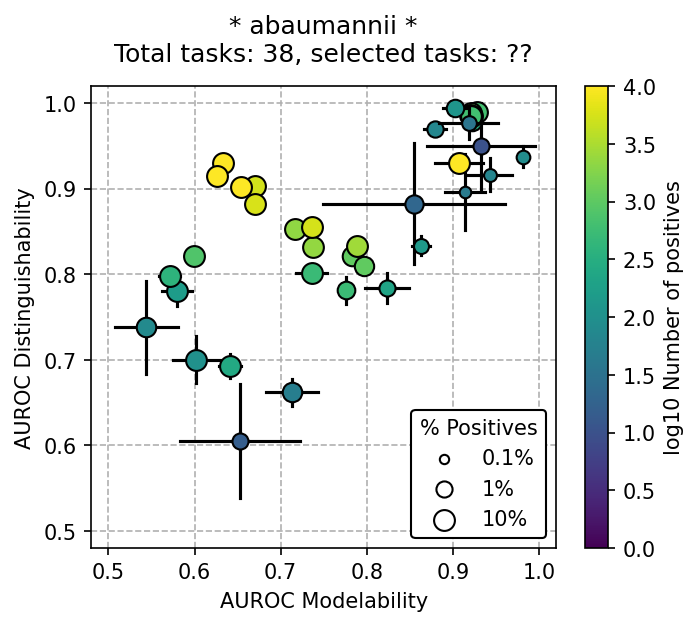

In [154]:
for pathogen in PATHOGENS:

    # Load modelability, distinguishability and summary
    modelability = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen, "014_modelability.csv"))
    distinguishability = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen, "015_distinguishability.csv"))
    summary = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen, f"017_{pathogen}_summary.csv"))
    
    # Create dicts
    tasks = sorted(set(modelability['task']))
    task_to_mod = {i: [j,k] for i,j,k in zip(modelability['task'], modelability['auroc_avg'], modelability['auroc_std'])}
    task_to_dist = {i: [j,k] for i,j,k in zip(distinguishability['task'], distinguishability['auroc_avg'], distinguishability['auroc_std'])}
    task_to_num = {i: [j,k] for i,j,k in zip(modelability['task'], modelability['num_samples'], modelability['num_pos_samples'])}

    # Plot summary
    plt.figure(figsize=(5, 4))
    plt.xlabel("AUROC Modelability")
    plt.ylabel("AUROC Distinguishability")

    for task in tasks:
        x, x_ = task_to_mod[task]
        y, y_ = task_to_dist[task]
        nums = task_to_num[task]
        positives = nums[1]
        s = nums[1] / nums[0] * 100
        s = map_value(s)
        c = np.log10(positives)

        plt.plot([x - x_/2, x + x_/2], [y, y], c='k', lw=1.5)  # std mod
        plt.plot([x, x], [y - y_/2, y + y_/2], c='k', lw=1.5)  # std dist
        sc = plt.scatter(x, y, s=s, c=[[c]], cmap='viridis', vmin=0, vmax=4, zorder=2, ec='k')
    
    # Title
    title =  f"* {pathogen} *\nTotal tasks: {summary['num tasks'].tolist()[0]}, selected tasks: {summary['num selected tasks'].tolist()[0]}"
    title =  f"* {pathogen} *\nTotal tasks: {summary['num tasks'].tolist()[0]}, selected tasks: ??"

    # Legends
    min_size, max_size = 20, 100
    legend_sizes = [20, 60, 100]  # Different dot sizes
    legend_labels = ["0.1%", "1%", "10%"]
    legend_handles = [plt.scatter([], [], s=size, color='white', ec='k') for size in legend_sizes]
    plt.legend(legend_handles, legend_labels, title="% Positives", loc="lower right", edgecolor='k', framealpha=1)


    plt.colorbar(sc, label="log10 Number of positives")
    plt.title(title, pad=12)
    plt.xlim([0.48, 1.02])
    plt.ylim([0.48, 1.02])
    plt.grid(linestyle='--')
    plt.show()


    break

In [135]:
positives

214

In [3]:
num_mols_original, num_mols_cleaned = [], []
num_tasks, num_modelable_tasks = [], []
names = []

for pathogen in PATHOGENS:

    # Read data
    # data_pathogen = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen, f"016_{pathogen}_summary.csv"))
    names.append(pathogen)

    # Number of molecules original
    try:
        num_mols_original.append(len(open(os.path.join(PATH_TO_OUTPUT, pathogen, f"011_{pathogen}_original.csv")).readlines()) - 1)
    except:
        num_mols_original.append(0)

    # Number of molecules cleaned
    try:
        num_mols_cleaned.append(len(open(os.path.join(PATH_TO_OUTPUT, pathogen, f"012_{pathogen}_cleaned.csv")).readlines()) - 1)
    except:
        num_mols_cleaned.append(0)

    # Number of tasks
    try:
        num_tasks.append(len(os.listdir(os.path.join(PATH_TO_OUTPUT, pathogen, "013_raw_tasks"))))
    except:
        num_tasks.append(0)

    # Number of selcted tasks
    try:
        num_modelable_tasks.append(len(os.listdir(os.path.join(PATH_TO_OUTPUT, pathogen, "016_tasks"))))
    except:
        num_modelable_tasks.append(0)


num_mols_original = np.array(num_mols_original)
num_mols_cleaned = np.array(num_mols_cleaned)
num_tasks = np.array(num_tasks)
num_modelable_tasks = np.array(num_modelable_tasks)
names = np.array(names)

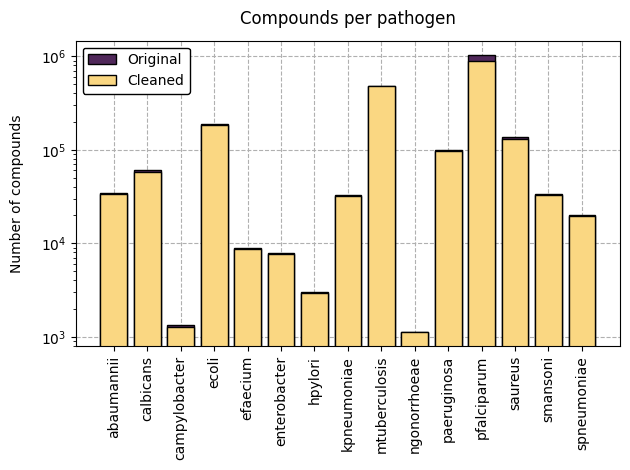

In [4]:
plt.bar([i for i in range(len(names))], num_mols_original, ec='k', color='#50285aff', zorder=2)
plt.bar([i for i in range(len(names))], num_mols_cleaned, ec='k', color='#fad782ff', zorder=2)
plt.yscale('log')
plt.xticks([i for i in range(len(names))], names, rotation=90)

plt.title("Compounds per pathogen", pad=12)
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Number of compounds", labelpad=12)
legend_patches = [mpatches.Patch(color='#50285aff', label='Original', ec='k'), mpatches.Patch(color='#fad782ff', label='Cleaned', ec='k')]
plt.legend(handles=legend_patches, loc='upper left', edgecolor='k', framealpha=1)
plt.tight_layout()
plt.savefig("../plots/num_compounds.png", dpi=300)
plt.show()

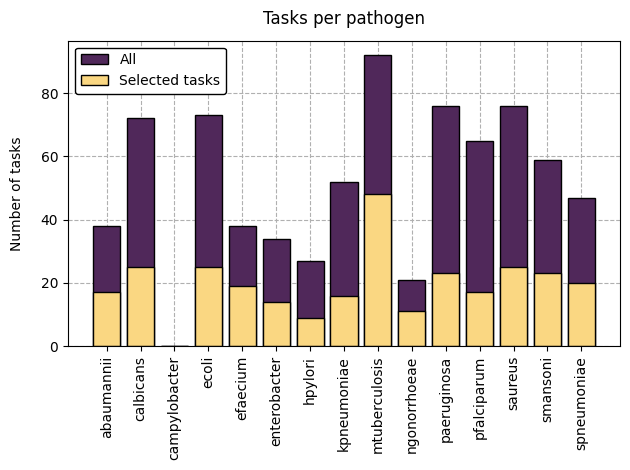

In [6]:
plt.bar([i for i in range(len(names))], num_tasks, ec='k', color='#50285aff', zorder=2)
plt.bar([i for i in range(len(names))], num_modelable_tasks, ec='k', color='#fad782ff', zorder=2)
plt.xticks([i for i in range(len(names))], names, rotation=90)

plt.title("Tasks per pathogen", pad=12)
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Number of tasks", labelpad=12)
legend_patches = [mpatches.Patch(color='#50285aff', label='All', ec='k'), mpatches.Patch(color='#fad782ff', label='Selected tasks', ec='k')]
plt.legend(handles=legend_patches, loc='upper left', edgecolor='k', framealpha=1)
plt.tight_layout()
plt.savefig("../plots/num_tasks.png", dpi=300)
plt.show()

abaumannii


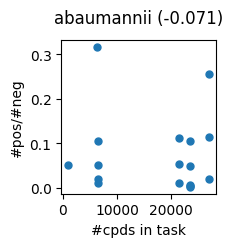

In [42]:
for name in names:

    if name != "campylobacter":

        # Load tasks data
        df = pd.read_csv(os.path.join(PATH_TO_OUTPUT, name, "016_tasks_summary.csv"))
        print(name)

        # Get data
        num_samples = df['num_samples'].tolist()
        pos_neg_prop = df['pos:neg'].tolist()
        corr = round(np.corrcoef(num_samples, pos_neg_prop)[0, 1], 3)

        plt.figure(figsize=(2, 2))
        plt.scatter(num_samples, pos_neg_prop, s=25)
        plt.title(name + f" ({corr})", pad=12)
        plt.xlabel("#cpds in task")
        plt.ylabel("#pos/#neg")
        plt.show()

    break

-0.071

In [20]:
num_samples

[21482,
 21482,
 21482,
 1032,
 6514,
 6533,
 6307,
 6524,
 6514,
 23407,
 23393,
 23392,
 23392,
 23392,
 26982,
 26886,
 27011]

In [9]:
num_mols_cleaned

array([ 33654,  58440,   1261, 181665,   8601,   7617,   2910,  32144,
       476773,   1116,  97026, 889813, 129537,  32678,  19409])

In [ ]:
num